In [63]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import lseg.data as ld
from lseg.data.discovery import Chain
from lseg.data.content import esg


In [ ]:
# ========== CONFIG ==========
INDEX_CHAIN = "0#.SPX"   # S&P 500 chain
INDEX_RIC   = ".SPX"     # benchmark index
START_DATE  = "2015-01-01"
END_DATE    = "2025-01-01"
N_SELECT    = 50         # number of lowest emitters
#EMISSIONS_COL_NAME = "Emissions Score"  # as shown in full_measures docs
#APP_KEY_PATH = "C:/Users/JanderM/lseg-data.config.json"
# ============================

ld.open_session()



<lseg.data.session.Definition object at 0x20011b40040 {name='workspace'}>

# 1 Data Extraction

In [65]:
# ---- STEP 1: Constituents ----
cons_file = "constituents.csv"
if os.path.exists(cons_file):
    tickers = pd.read_csv(cons_file)["RIC"].tolist()
else:
    cons = Chain(INDEX_CHAIN)
    tickers = cons.constituents
    pd.DataFrame({"RIC": tickers}).to_csv(cons_file, index=False)

print("Number of constituents:", len(tickers))
print("Sample tickers:", tickers)



Number of constituents: 503
Sample tickers: ['A.N', 'AAPL.OQ', 'ABBV.N', 'ABNB.OQ', 'ABT.N', 'ACGL.OQ', 'ACN.N', 'ADBE.OQ', 'ADI.OQ', 'ADM.N', 'ADP.OQ', 'ADSK.OQ', 'AEE.N', 'AEP.OQ', 'AES.N', 'AFL.N', 'AIG.N', 'AIZ.N', 'AJG.N', 'AKAM.OQ', 'ALB.N', 'ALGN.OQ', 'ALL.N', 'ALLE.N', 'AMAT.OQ', 'AMCR.N', 'AMD.OQ', 'AME.N', 'AMGN.OQ', 'AMP.N', 'AMT.N', 'AMZN.OQ', 'ANET.N', 'AON.N', 'AOS.N', 'APA.OQ', 'APD.N', 'APH.N', 'APO.N', 'APTV.N', 'ARE.N', 'ATO.N', 'AVB.N', 'AVGO.OQ', 'AVY.N', 'AWK.N', 'AXON.OQ', 'AXP.N', 'AZO.N', 'BA.N', 'BAC.N', 'BALL.N', 'BAX.N', 'BBY.N', 'BDX.N', 'BEN.N', 'BFb.N', 'BG.N', 'BIIB.OQ', 'BK.N', 'BKNG.OQ', 'BKR.OQ', 'BLDR.N', 'BLK.N', 'BMY.N', 'BR.N', 'BRKb.N', 'BRO.N', 'BSX.N', 'BX.N', 'BXP.N', 'C.N', 'CAG.N', 'CAH.N', 'CARR.N', 'CAT.N', 'CB.N', 'CBOE.Z', 'CBRE.N', 'CCI.N', 'CCL.N', 'CDNS.OQ', 'CDW.OQ', 'CEG.OQ', 'CF.N', 'CFG.N', 'CHD.N', 'CHRW.OQ', 'CHTR.OQ', 'CI.N', 'CINF.OQ', 'CL.N', 'CLX.N', 'CMCSA.OQ', 'CME.OQ', 'CMG.N', 'CMI.N', 'CMS.N', 'CNC.N', 'CNP.N', 'COF.N', 

In [66]:

carbon_file = "sp500_carbon_emissions_snapshots.csv"

if os.path.exists(carbon_file):
    print(f"Loading cached carbon emissions data from {carbon_file}...")
    carbon_df = pd.read_csv(carbon_file)
else:
    print("Fetching ESG snapshot data from LSEG...")
    carbon_df = ld.get_data(universe=tickers, fields=["TR.CO2EmissionTotal "])
    carbon_df.to_csv(carbon_file, index=False)
    print(f"Saved carrbon emissions data to {carbon_file}")

print(carbon_df.head())


Loading cached carbon emissions data from sp500_carbon_emissions_snapshots.csv...
  Instrument  CO2 Equivalent Emissions Total
0        A.N                         68619.0
1    AAPL.OQ                       1279700.0
2     ABBV.N                        541214.0
3    ABNB.OQ                          7363.0
4      ABT.N                        981000.0


In [67]:
# ---- STEP 3: Select Lowest Emitters ----
low_emitters = carbon_df.sort_values("CO2 Equivalent Emissions Total").head(N_SELECT)["Instrument"].tolist()
print("Selected assets:", low_emitters[:10], "...")



Selected assets: ['CPAY.N', 'O.N', 'MKTX.OQ', 'EG.N', 'DDOG.OQ', 'VICI.N', 'BKNG.OQ', 'PLTR.OQ', 'XYZ.N', 'MTCH.OQ'] ...


In [68]:
# ---- STEP 4: Prices ----
prices_file = "prices.csv"
if os.path.exists(prices_file):
    prices_wide = pd.read_csv(prices_file, index_col="Date", parse_dates=True)
else:
    prices = ld.get_history(
        universe=low_emitters,
        fields=["TR.PriceClose"],
        start=START_DATE,
        end=END_DATE,
        interval="daily"
    )
    prices.to_csv(prices_file, index=False)

ld.close_session()


c:\Users\JanderM\AppData\Local\anaconda3\envs\green-finance\lib\site-packages\lseg\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [77]:
prices.to_csv(prices_file, index=False)

In [69]:
prices.head()

Price Close,CPAY.N,O.N,MKTX.OQ,EG.N,DDOG.OQ,VICI.N,BKNG.OQ,PLTR.OQ,XYZ.N,MTCH.OQ,...,ZBRA.OQ,TRMB.OQ,INCY.OQ,ENPH.OQ,TTWO.OQ,TPR.N,SYF.N,HIG.N,PANW.OQ,EXPE.OQ
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,150.26,47.082684,70.35,168.82,<NA>,<NA>,1142.06,<NA>,<NA>,<NA>,...,77.43,26.91,73.76,14.21,28.095,37.31,29.48,41.79,20.236646,85.76
2015-01-05,143.78,48.051065,68.99,167.91,<NA>,<NA>,1097.58,<NA>,<NA>,<NA>,...,76.34,26.03,74.22,13.88,27.62,36.73,29.25,40.91,20.621646,84.2
2015-01-06,142.25,48.680513,67.66,168.97,<NA>,<NA>,1079.96,<NA>,<NA>,<NA>,...,75.79,25.655,71.49,12.94,27.93,36.3,28.85,40.24,20.308313,84.17
2015-01-07,143.21,49.474585,68.27,170.11,<NA>,<NA>,1069.57,<NA>,<NA>,<NA>,...,77.72,25.34,74.45,11.4,28.1,37.42,29.2,40.62,20.921646,84.17
2015-01-08,146.12,48.167271,71.7,174.96,<NA>,<NA>,1082.85,<NA>,<NA>,<NA>,...,79.38,25.67,73.21,11.73,28.46,38.37,29.98,41.06,21.201645,87.89


In [70]:
# Keep only assets with full 10Y data (no NA)
valid_assets = prices.dropna(axis=1).columns
prices = prices[valid_assets]
returns = prices.pct_change().dropna()

print("Number of valid assets:", len(valid_assets))
print(returns.head())

Number of valid assets: 42
Price Close    CPAY.N       O.N   MKTX.OQ      EG.N   BKNG.OQ   PAYX.OQ  \
Date                                                                      
2015-01-05  -0.043125  0.020568 -0.019332  -0.00539 -0.038947   0.00173   
2015-01-06  -0.010641    0.0131 -0.019278  0.006313 -0.016053 -0.007124   
2015-01-07   0.006749  0.016312  0.009016  0.006747 -0.009621  0.018265   
2015-01-08    0.02032 -0.026424  0.050242  0.028511  0.012416  0.015588   
2015-01-09  -0.017588  0.011862  -0.00265 -0.019204 -0.028527 -0.008831   

Price Close      GL.N     KKR.N   VRSK.OQ    MSCI.N  ...   ZBRA.OQ   TRMB.OQ  \
Date                                                 ...                       
2015-01-05   -0.01791 -0.006386 -0.012975 -0.009436  ... -0.014077 -0.032702   
2015-01-06  -0.013536 -0.009854 -0.003484  0.029001  ... -0.007205 -0.014406   
2015-01-07   0.001144  0.018607  0.000636  0.022835  ...  0.025465 -0.012278   
2015-01-08    0.01542 -0.005947  0.010006  0.03

# 2 Portfolio Optimization
## 2.1 5 Year Data

In [71]:
# filter returns to first 4 years for in-sample and 5th year for out-of-sample
returns_15_19 = returns.loc["2015":"2019"]
returns_20 = returns.loc["2020"]

returns_15_19

Price Close,CPAY.N,O.N,MKTX.OQ,EG.N,BKNG.OQ,PAYX.OQ,GL.N,KKR.N,VRSK.OQ,MSCI.N,...,ZBRA.OQ,TRMB.OQ,INCY.OQ,ENPH.OQ,TTWO.OQ,TPR.N,SYF.N,HIG.N,PANW.OQ,EXPE.OQ
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.043125,0.020568,-0.019332,-0.00539,-0.038947,0.00173,-0.01791,-0.006386,-0.012975,-0.009436,...,-0.014077,-0.032702,0.006236,-0.023223,-0.016907,-0.015545,-0.007802,-0.021058,0.019025,-0.01819
2015-01-06,-0.010641,0.0131,-0.019278,0.006313,-0.016053,-0.007124,-0.013536,-0.009854,-0.003484,0.029001,...,-0.007205,-0.014406,-0.036783,-0.067723,0.011224,-0.011707,-0.013675,-0.016377,-0.015194,-0.000356
2015-01-07,0.006749,0.016312,0.009016,0.006747,-0.009621,0.018265,0.001144,0.018607,0.000636,0.022835,...,0.025465,-0.012278,0.041404,-0.119011,0.006087,0.030854,0.012132,0.009443,0.030201,0.0
2015-01-08,0.02032,-0.026424,0.050242,0.028511,0.012416,0.015588,0.01542,-0.005947,0.010006,0.030169,...,0.021359,0.013023,-0.016655,0.028947,0.012811,0.025387,0.026712,0.010832,0.013383,0.044196
2015-01-09,-0.017588,0.011862,-0.00265,-0.019204,-0.028527,-0.008831,-0.014436,0.01453,-0.007863,0.014643,...,0.014613,-0.001948,-0.016118,-0.01705,-0.020731,-0.004431,-0.00934,-0.009255,-0.010927,-0.003868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,0.003198,0.005698,0.007324,0.003656,0.005856,-0.003062,0.003403,-0.001377,-0.002541,0.006339,...,-0.009348,-0.000118,0.014086,0.007833,0.014821,-0.01292,-0.000275,-0.000666,0.001989,0.00713
2019-12-26,-0.008652,0.006633,0.0054,0.000255,0.009941,0.000709,-0.001602,0.009655,-0.002279,0.000461,...,0.000354,-0.000946,-0.028929,0.011843,0.000484,0.018325,-0.001652,0.003497,0.00755,0.002758
2019-12-27,0.009965,0.005629,-0.002925,0.005245,0.003982,0.00484,-0.001038,-0.003757,-0.00168,-0.001881,...,0.00621,-0.006862,-0.004449,-0.021397,0.003871,-0.012853,0.000827,0.004812,-0.001156,-0.006876


In [72]:
# ---- STEP 5: Mean & Covariance ----
mu_15_19 = returns_15_19.mean() * 252   # annualized mean
sigma_15_19 = returns_15_19.cov() * 252 # annualized covariance

print("Mean returns (annualized):")
print(mu_15_19.head())
print("\nCovariance matrix (annualized):")
print(sigma_15_19.head())


Mean returns (annualized):
Price Close
CPAY.N      0.16423
O.N        0.101904
MKTX.OQ    0.373995
EG.N        0.11695
BKNG.OQ      0.1512
dtype: Float64

Covariance matrix (annualized):
Price Close    CPAY.N       O.N   MKTX.OQ      EG.N   BKNG.OQ   PAYX.OQ  \
Price Close                                                               
CPAY.N       0.068156  0.006577  0.016061  0.009257  0.025238  0.019884   
O.N          0.006577  0.037252  0.009099  0.006774  0.004214  0.010941   
MKTX.OQ      0.016061  0.009099  0.072027  0.011387  0.012679  0.013188   
EG.N         0.009257  0.006774  0.011387  0.035626  0.010776  0.011708   
BKNG.OQ      0.025238  0.004214  0.012679  0.010776  0.066342  0.016842   

Price Close      GL.N     KKR.N   VRSK.OQ    MSCI.N  ...   ZBRA.OQ   TRMB.OQ  \
Price Close                                          ...                       
CPAY.N       0.018763  0.030088  0.018924  0.027336  ...  0.036342  0.030889   
O.N          0.003196  0.003440  0.009282  0.01

In [73]:
# check for NaNs in mu and sigma
print(mu_15_19.isna().sum())
print(sigma_15_19.isna().sum().sum())


0
0


In [74]:
# check values of mu and sigma
print(mu_15_19.describe())
print(sigma_15_19.iloc[:5, :5])


count        42.0
mean     0.178817
std      0.109845
min     -0.118247
25%      0.123586
50%      0.159962
75%       0.20528
max      0.489446
dtype: Float64
Price Close    CPAY.N       O.N   MKTX.OQ      EG.N   BKNG.OQ
Price Close                                                  
CPAY.N       0.068156  0.006577  0.016061  0.009257  0.025238
O.N          0.006577  0.037252  0.009099  0.006774  0.004214
MKTX.OQ      0.016061  0.009099  0.072027  0.011387  0.012679
EG.N         0.009257  0.006774  0.011387  0.035626  0.010776
BKNG.OQ      0.025238  0.004214  0.012679  0.010776  0.066342


In [75]:
# ---- STEP 6: Compute Efficient Frontier ----

def compute_efficient_frontier(mu, Sigma, n_points=50, solver="SCS"):
    num_assets = len(mu)
    rets, vols, weights = [], [], []

    # Get min and max returns
    w_min_var = cp.Variable(num_assets)
    risk = cp.quad_form(w_min_var, Sigma)
    constraints = [cp.sum(w_min_var) == 1, w_min_var >= 0]
    cp.Problem(cp.Minimize(risk), constraints).solve(solver=solver)
    min_ret = float(mu.to_numpy() @ w_min_var.value)

    max_ret = float(mu.max()) * 0.99
    target_returns = np.linspace(min_ret, max_ret, n_points)

    for target in target_returns:
        w = cp.Variable(num_assets)
        risk = cp.quad_form(w, Sigma)
        constraints = [
            cp.sum(w) == 1,
            mu.values @ w >= target,
            w >= 0
        ]
        prob = cp.Problem(cp.Minimize(risk), constraints)
        try:
            prob.solve(solver=solver)
            if w.value is not None and prob.status == cp.OPTIMAL:
                weights.append(w.value)
                rets.append(mu.to_numpy() @ w.value)
                vols.append(np.sqrt(w.value.T @ Sigma.to_numpy() @ w.value))
            else:
                weights.append([np.nan]*num_assets)
                rets.append(np.nan)
                vols.append(np.nan)
        except:
            weights.append([np.nan]*num_assets)
            rets.append(np.nan)
            vols.append(np.nan)

    return np.array(vols), np.array(rets), np.array(weights)

vols_15_19, rets_15_19, weights_15_19 = compute_efficient_frontier(mu_15_19, sigma_15_19)


In [83]:
mu_20 = returns_20.mean() * 252   # annualized mean
sigma_20 = returns_20.cov() * 252 # annualized covariance


# Evaluate performance on test data
rets_20 = weights_15_19 @ mu_20  # shape (50,)
vols_20 = np.sqrt(np.einsum('ij,ji->i', weights_15_19 @ sigma_20.values, weights_15_19.T))


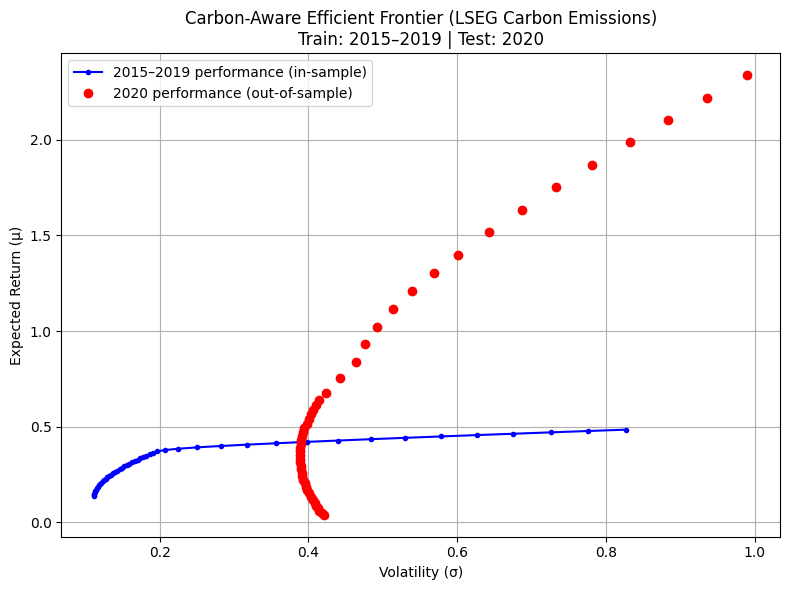

In [89]:
# ---- STEP 7: Plot ----
plt.figure(figsize=(8,6))
plt.plot(vols_15_19, rets_15_19, "b.-", label="2015–2019 performance (in-sample)")
plt.plot(vols_20, rets_20, "ro", label="2020 performance (out-of-sample)")
plt.xlabel("Volatility (σ)")
plt.ylabel("Expected Return (μ)")
plt.title("Carbon-Aware Efficient Frontier (LSEG Carbon Emissions)\nTrain: 2015–2019 | Test: 2020")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2.2 10 Year Data

In [86]:
# In-sample: 2015–2023
returns_15_23 = returns.loc["2015":"2023"]

# Out-of-sample: 2024–2025
returns_24_25 = returns.loc["2024":"2025"]

In [87]:
# Step 5: Mean & Covariance
mu_15_23 = returns_15_23.mean() * 252
sigma_15_23 = returns_15_23.cov() * 252

# Efficient frontier
vols_15_23, rets_15_23, weights_15_23 = compute_efficient_frontier(mu_15_23, sigma_15_23)

# Out-of-sample stats
mu_24_25 = returns_24_25.mean() * 252
sigma_24_25 = returns_24_25.cov() * 252

rets_24_25 = weights_15_23 @ mu_24_25
vols_24_25 = np.sqrt(np.einsum('ij,jk,ik->i', weights_15_23, sigma_24_25.values, weights_15_23))


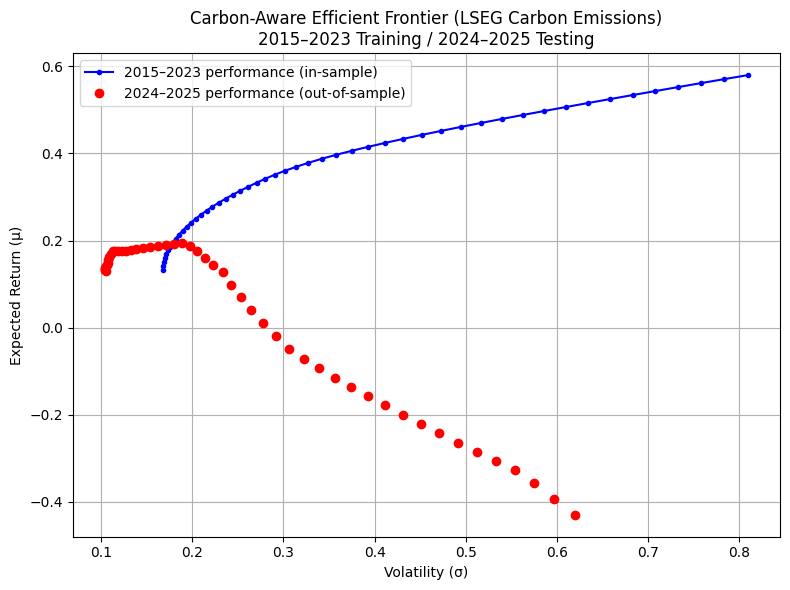

In [88]:
# ---- STEP 7: Plot ----
plt.figure(figsize=(8,6))
plt.plot(vols_15_23, rets_15_23, "b.-", label="2015–2023 performance (in-sample)")
plt.plot(vols_24_25, rets_24_25, "ro", label="2024–2025 performance (out-of-sample)")
plt.xlabel("Volatility (σ)")
plt.ylabel("Expected Return (μ)")
plt.title("Carbon-Aware Efficient Frontier (LSEG Carbon Emissions)\n2015–2023 Training / 2024–2025 Testing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
